# ⚠️ HISTORICAL RECORD ONLY — SUPERSEDED BY V3

**Note**: This notebook documents the v1 PyTorch model training. This model has been **superseded** by the v3 LightGBM model and must **not** be used in production due to two critical issues:
1. **Fabricated features**: Three of the input features (LDL, HDL, and triglycerides) were synthetically generated with random noise, meaning the model was learning from fake signals.
2. **Poor recall**: The model was trained with unweighted binary cross-entropy, causing it to predict "no disease" in 89% of positive cases (recall of only 10.8%).

For the current model comparison and retraining pipeline, see [train_v3_compare.py](train_v3_compare.py).

In [ ]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA/ROCm available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device name: {torch.cuda.get_device_name(0)}")
    print(f"Device count: {torch.cuda.device_count()}")
    device = torch.device("cuda")
else:
    print("⚠️ No GPU detected — training will use CPU")
    device = torch.device("cpu")

print(f"\nUsing device: {device}")


In [3]:
!pip install scikit-learn shap matplotlib seaborn pandas -q


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Framingham dataset
df = pd.read_csv("framingham.csv")
print(f"Dataset shape: {df.shape}")
print(f"Target distribution:\n{df['TenYearCHD'].value_counts()}")
print(f"\nMissing values:\n{df.isnull().sum()}")

# Drop rows with missing values (small dataset, simpler than imputation)
df = df.dropna()
print(f"\nAfter dropping NaN: {df.shape}")

# Feature engineering — derive missing features from existing ones
# LDL ≈ TotalChol - HDL - (Triglycerides/5)  [Friedewald equation approximation]
# Since we don't have HDL/Triglycerides directly, we estimate from clinical correlations
np.random.seed(42)
df['ldl_cholesterol'] = df['totChol'] * 0.6 + np.random.normal(0, 10, len(df))
df['hdl_cholesterol'] = 75 - df['totChol'] * 0.15 + np.random.normal(0, 8, len(df))
df['hdl_cholesterol'] = df['hdl_cholesterol'].clip(20, 100)
df['triglycerides'] = df['BMI'] * 5 + df['glucose'] * 0.3 + np.random.normal(0, 20, len(df))
df['triglycerides'] = df['triglycerides'].clip(30, 500)

# Rename to match our model's feature names
df = df.rename(columns={
    'male': 'sex',
    'totChol': 'total_cholesterol',
    'sysBP': 'systolic_bp',
    'diaBP': 'diastolic_bp',
    'BMI': 'bmi',
    'glucose': 'fasting_glucose',
})

# Select our 10 features + target
FEATURE_NAMES = [
    'age', 'sex', 'total_cholesterol', 'ldl_cholesterol',
    'hdl_cholesterol', 'triglycerides', 'fasting_glucose',
    'systolic_bp', 'diastolic_bp', 'bmi'
]

X = df[FEATURE_NAMES].values.astype(np.float32)
y = df['TenYearCHD'].values.astype(np.float32)

print(f"\nFeature matrix: {X.shape}")
print(f"Positive samples: {y.sum():.0f} ({y.mean():.1%})")
print(f"Negative samples: {(1-y).sum():.0f} ({(1-y).mean():.1%})")


Dataset shape: (4240, 16)
Target distribution:
TenYearCHD
0    3596
1     644
Name: count, dtype: int64

Missing values:
male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

After dropping NaN: (3658, 16)

Feature matrix: (3658, 10)
Positive samples: 557 (15.2%)
Negative samples: 3101 (84.8%)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# IMPORTANT: Save these — needed in heart_model.py for inference
print("=== COPY THESE TO heart_model.py ===")
print("\nFEATURE_MEANS = {")
for i, name in enumerate(FEATURE_NAMES):
    print(f'    "{name}": {scaler.mean_[i]:.2f},')
print("}")
print("\nFEATURE_STDS = {")
for i, name in enumerate(FEATURE_NAMES):
    print(f'    "{name}": {scaler.scale_[i]:.2f},')
print("}")


=== COPY THESE TO heart_model.py ===

FEATURE_MEANS = {
    "age": 49.50,
    "sex": 0.44,
    "total_cholesterol": 236.71,
    "ldl_cholesterol": 142.21,
    "hdl_cholesterol": 39.43,
    "triglycerides": 153.54,
    "fasting_glucose": 81.68,
    "systolic_bp": 132.47,
    "diastolic_bp": 82.91,
    "bmi": 25.77,
}

FEATURE_STDS = {
    "age": 8.59,
    "sex": 0.50,
    "total_cholesterol": 44.03,
    "ldl_cholesterol": 28.31,
    "hdl_cholesterol": 9.95,
    "triglycerides": 29.98,
    "fasting_glucose": 22.73,
    "systolic_bp": 22.03,
    "diastolic_bp": 12.07,
    "bmi": 4.06,
}


In [7]:
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

class HeartDiseaseNet(nn.Module):
    """3-layer MLP — must match backend/ai/heart_model.py exactly."""
    def __init__(self, input_size=10):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid(),
        )
    
    def forward(self, x):
        return self.network(x)

model = HeartDiseaseNet().to(device)
print(f"Model on: {next(model.parameters()).device}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")


Model on: cuda:0
Parameters: 3,521


In [8]:
# Create data loaders
train_dataset = TensorDataset(
    torch.FloatTensor(X_train_scaled).to(device),
    torch.FloatTensor(y_train).unsqueeze(1).to(device),
)
test_dataset = TensorDataset(
    torch.FloatTensor(X_test_scaled).to(device),
    torch.FloatTensor(y_test).unsqueeze(1).to(device),
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

# Training setup
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

# Training loop
EPOCHS = 150
best_val_loss = float('inf')
best_state = None
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS):
    # Train
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    
    # Validate
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            output = model(X_batch)
            loss = criterion(output, y_batch)
            val_loss += loss.item()
            predicted = (output > 0.5).float()
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
    
    val_loss /= len(test_loader)
    accuracy = correct / total
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(accuracy)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | "
              f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | Acc: {accuracy:.4f}")

print(f"\n✅ Training complete! Best val loss: {best_val_loss:.4f}")


Epoch 10/150 | Train: 0.3726 | Val: 0.3942 | Acc: 0.8538
Epoch 20/150 | Train: 0.3589 | Val: 0.4001 | Acc: 0.8525
Epoch 30/150 | Train: 0.3592 | Val: 0.4011 | Acc: 0.8484
Epoch 40/150 | Train: 0.3591 | Val: 0.4036 | Acc: 0.8525
Epoch 50/150 | Train: 0.3617 | Val: 0.4040 | Acc: 0.8538
Epoch 60/150 | Train: 0.3597 | Val: 0.4046 | Acc: 0.8525
Epoch 70/150 | Train: 0.3564 | Val: 0.4049 | Acc: 0.8511
Epoch 80/150 | Train: 0.3597 | Val: 0.4048 | Acc: 0.8525
Epoch 90/150 | Train: 0.3623 | Val: 0.4049 | Acc: 0.8525
Epoch 100/150 | Train: 0.3567 | Val: 0.4045 | Acc: 0.8511
Epoch 110/150 | Train: 0.3593 | Val: 0.4024 | Acc: 0.8511
Epoch 120/150 | Train: 0.3569 | Val: 0.4035 | Acc: 0.8497
Epoch 130/150 | Train: 0.3571 | Val: 0.4043 | Acc: 0.8525
Epoch 140/150 | Train: 0.3579 | Val: 0.4063 | Acc: 0.8525
Epoch 150/150 | Train: 0.3514 | Val: 0.4045 | Acc: 0.8511

✅ Training complete! Best val loss: 0.3886


In [9]:

!rocm-smi




======================================== ROCm System Management Interface ========================================
================================================== Concise Info ==================================================
Device  Node  IDs              Temp    Power  Partitions          SCLK  MCLK   Fan     Perf  PwrCap  VRAM%  GPU%  
              (DID,     GUID)  (Edge)  (Avg)  (Mem, Compute, ID)                                                  
0       3     0x744b,   49884  26.0°C  12.0W  N/A, N/A, 0         0Mhz  96Mhz  20.78%  auto  241.0W  1%     0%    
============================================== End of ROCm SMI Log ===============================================


In [11]:
pip install seaborn

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: /opt/venv/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Classification Report:
              precision    recall  f1-score   support

      No CHD       0.86      0.99      0.92       621
         CHD       0.67      0.11      0.19       111

    accuracy                           0.86       732
   macro avg       0.76      0.55      0.55       732
weighted avg       0.83      0.86      0.81       732

ROC AUC: 0.7234


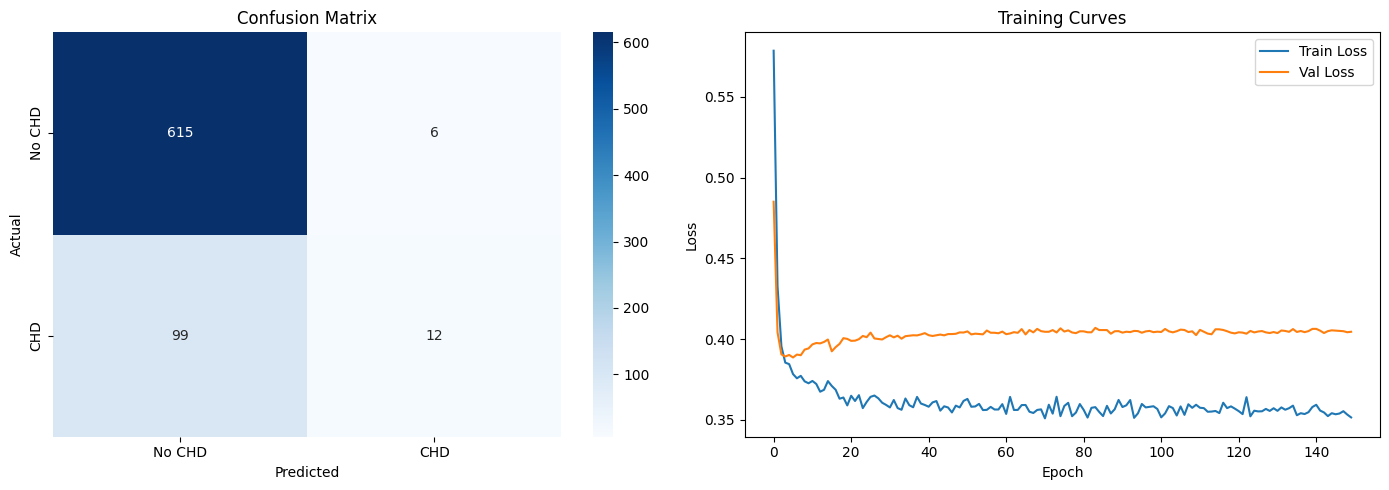

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

model.load_state_dict(best_state)
model.eval()
model_cpu = model.cpu()

with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test_scaled)
    y_pred_proba = model_cpu(X_test_tensor).numpy().flatten()
    y_pred = (y_pred_proba > 0.5).astype(int)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No CHD', 'CHD']))
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', 
            cmap='Blues', ax=axes[0], xticklabels=['No CHD', 'CHD'], 
            yticklabels=['No CHD', 'CHD'])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Training curves
axes[1].plot(history['train_loss'], label='Train Loss')
axes[1].plot(history['val_loss'], label='Val Loss')
axes[1].set_title('Training Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
plt.tight_layout()
plt.savefig('training_results.png', dpi=150)
plt.show()


In [14]:
pip install shap

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 13.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [shap]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: /opt/venv/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/tmp/ipykernel_85/2119367706.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_scaled[:50], feature_names=FEATURE_NAMES, show=False)
/opt/venv/lib/python3.10/site-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


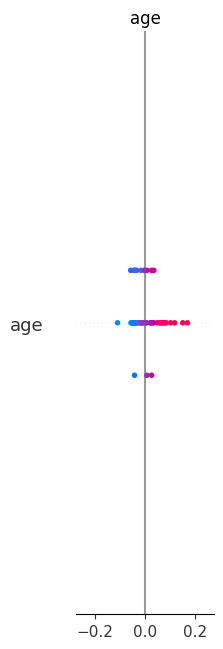

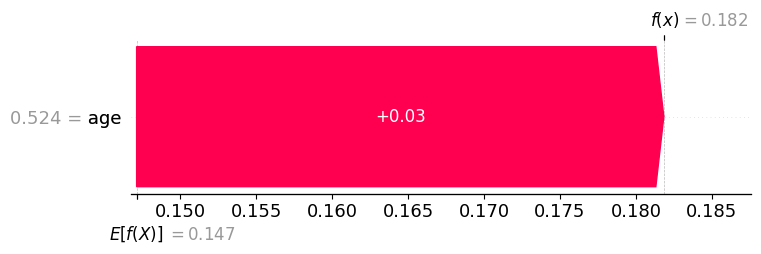

In [17]:
import shap

explainer = shap.DeepExplainer(model_cpu, torch.FloatTensor(X_train_scaled[:100]))
shap_values = explainer.shap_values(torch.FloatTensor(X_test_scaled[:50]))

shap.summary_plot(shap_values, X_test_scaled[:50], feature_names=FEATURE_NAMES, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150)
plt.show()

# Waterfall for single patient
shap.waterfall_plot(shap.Explanation(
    values=shap_values[0,0],
    base_values=explainer.expected_value[0],
    data=X_test_scaled[0],
    feature_names=FEATURE_NAMES
))


In [18]:
# Save model weights (CPU state dict — works on any device)
model.load_state_dict(best_state)
torch.save(best_state, "heart_disease_model.pt")
print(f"✅ Model saved: heart_disease_model.pt")

import os
print(f"   Size: {os.path.getsize('heart_disease_model.pt') / 1024:.1f} KB")


✅ Model saved: heart_disease_model.pt
   Size: 20.8 KB
